In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [34]:
import os


print("Current Dir:", os.getcwd())
print("Files/Folders:", os.listdir())

Current Dir: d:\GITHUB\restaurant-ml-project\notebooks
Files/Folders: ['EDA_and_Preprocessing.ipynb', 'Task1_Rating_Prediction.ipynb', 'Task2_Recommendation_System.ipynb', 'Task3_Cuisine_Classification.ipynb', 'Task4_Location_Analysis.ipynb']


## 📊 Exploratory Data Analysis & Preprocessing
This notebook covers:
1. Loading and understanding the dataset
2. Identifying missing values and outliers
3. Visual exploration of key features
4. Cleaning and encoding for ML tasks
5. Saving the cleaned dataset for use in other notebooks

In [54]:
df = pd.read_csv('../data/restaurant_dataset.csv', encoding='utf-8-sig')

print(f"Dataset Shape: {df.shape}")
print(f"Total Restaurants: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
df.head()

Dataset Shape: (9551, 21)
Total Restaurants: 9551
Total Features: 21


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [55]:
# Checking data types and missing values
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch t

In [56]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Columns with Missing Values:")
print(missing_df)

Columns with Missing Values:
          Missing Count  Missing %
Cuisines              9   0.094231


Rating Distribution:
Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64

Restaurants with 0 rating (not yet rated): 2148
Rated restaurants: 7403


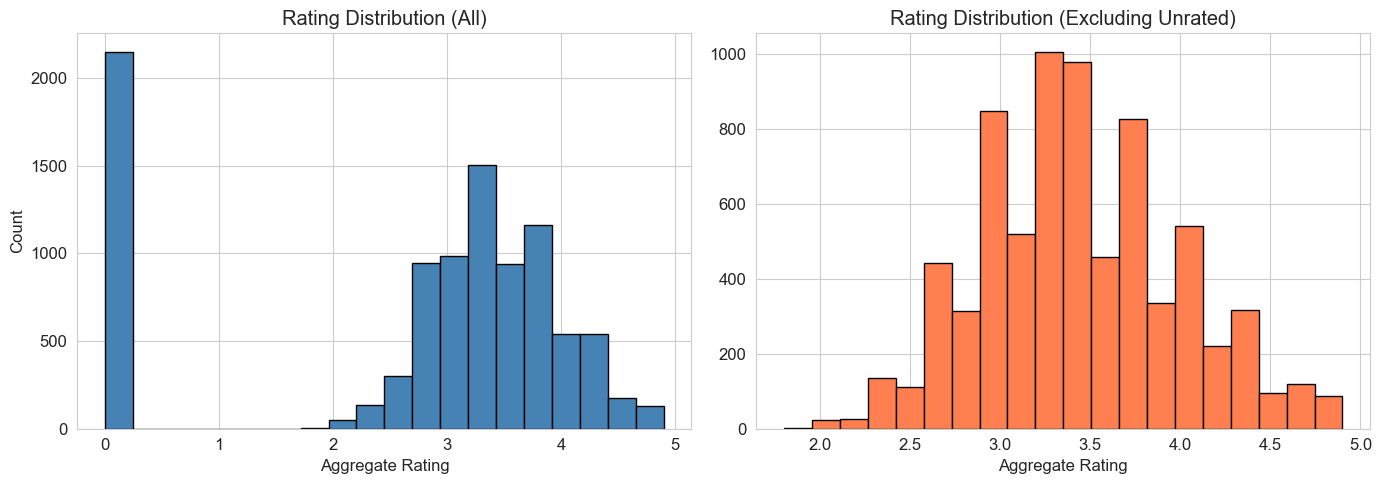

Plot saved to plots/


In [57]:
#Important: Restaurants with 0 rating = "Not yet rated"
print("Rating Distribution:")
print(df['Aggregate rating'].value_counts().sort_index())

print(f"\nRestaurants with 0 rating (not yet rated): {(df['Aggregate rating'] == 0).sum()}")
print(f"Rated restaurants: {(df['Aggregate rating'] > 0).sum()}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All data
axes[0].hist(df['Aggregate rating'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Rating Distribution (All)')
axes[0].set_xlabel('Aggregate Rating')
axes[0].set_ylabel('Count')

# Excluding 0 ratings
rated = df[df['Aggregate rating'] > 0]
axes[1].hist(rated['Aggregate rating'], bins=20, color='coral', edgecolor='black')
axes[1].set_title('Rating Distribution (Excluding Unrated)')
axes[1].set_xlabel('Aggregate Rating')

plt.tight_layout()
plt.savefig('D:/GITHUB/restaurant-ml-project/plots/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to plots/")

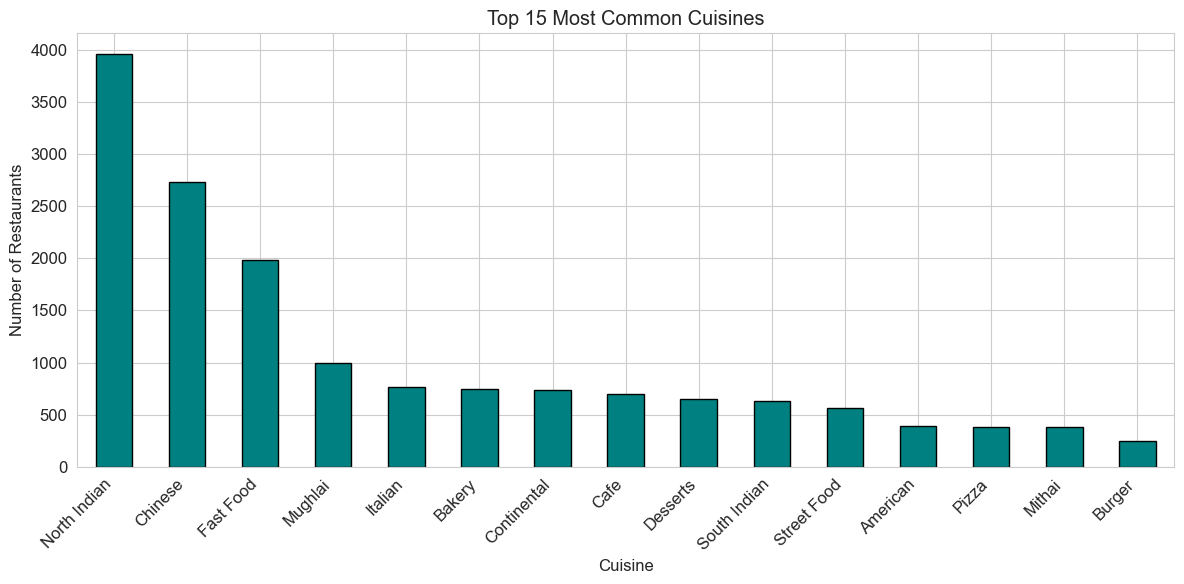

In [58]:
# Cuisines analysis
cuisines_series = df['Cuisines'].dropna().str.split(', ').explode()
top_cuisines = cuisines_series.value_counts().head(15)

plt.figure(figsize=(12, 6))
top_cuisines.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 15 Most Common Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/top_cuisines.png', dpi=150, bbox_inches='tight')
plt.show()

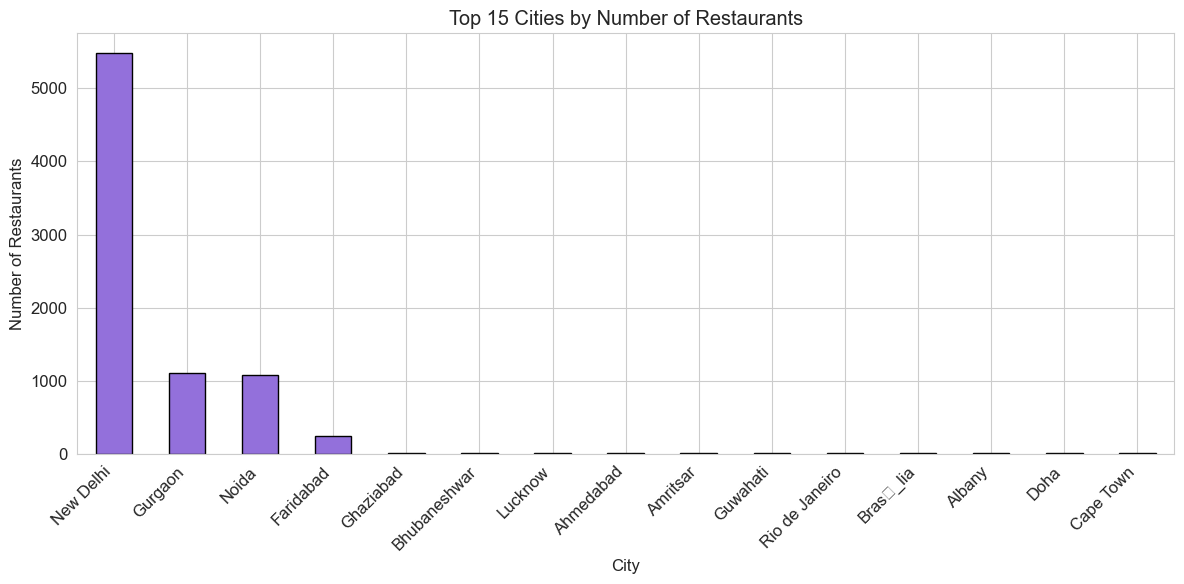

In [59]:
# Top Cities
top_cities = df['City'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_cities.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Top 15 Cities by Number of Restaurants')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/top_cities.png', dpi=150, bbox_inches='tight')
plt.show()

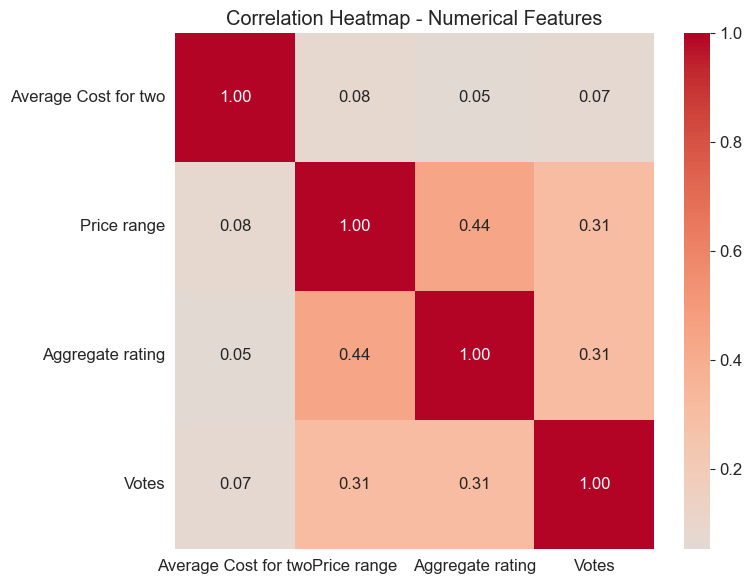

In [60]:
# Only numerical columns
numerical_cols = ['Average Cost for two', 'Price range', 
                  'Aggregate rating', 'Votes']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.savefig('../plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [63]:
# PREPROCESSING

df_clean = df.copy()

# 1. Drop missing Cuisines rows (only 9 rows)
df_clean = df_clean.dropna(subset=['Cuisines'])
print(f"After dropping missing cuisines: {df_clean.shape}")

# 2. Drop leakage columns and irrelevant columns
cols_to_drop = [
    'Restaurant ID',      # ID, not useful
    'Address',            # Too specific
    'Locality Verbose',   # Duplicate of Locality
    'Rating color',       # Derived from Aggregate rating → DATA LEAKAGE
    'Rating text',        # Derived from Aggregate rating → DATA LEAKAGE
    'Switch to order menu', # Almost all same value
    'Currency'            # Redundant with Country Code
]
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"After dropping irrelevant columns: {df_clean.shape}")

# 3. Encode Yes/No columns
binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now']
for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})

print("Binary columns encoded")

# 4. Create a separate version for ML (exclude unrated restaurants)
df_rated = df_clean[df_clean['Aggregate rating'] > 0].copy()
print(f"\nRated restaurants (for ML tasks): {df_rated.shape[0]}")
print(f"Unrated restaurants (excluded from ML): {(df_clean['Aggregate rating'] == 0).sum()}")

df_clean.head()

After dropping missing cuisines: (9542, 21)
After dropping irrelevant columns: (9542, 14)
Binary columns encoded

Rated restaurants (for ML tasks): 7394
Unrated restaurants (excluded from ML): 2148


,Restaurant Name,Country Code,City,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes
0,Le Petit Souffle,162,Makati City,"Century City Mall, Poblacion, Makati City",121.027535,14.565443,"French, Japanese, Desserts",1100,1,0,0,3,4.8,314
1,Izakaya Kikufuji,162,Makati City,"Little Tokyo, Legaspi Village, Makati City",121.014101,14.553708,Japanese,1200,1,0,0,3,4.5,591
2,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, Ortigas, Mandaluyong City",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,1,0,0,4,4.4,270
3,Ooma,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.056475,14.585318,"Japanese, Sushi",1500,0,0,0,4,4.9,365
4,Sambo Kojin,162,Mandaluyong City,"SM Megamall, Ortigas, Mandaluyong City",121.057508,14.584450,"Japanese, Korean",1500,1,0,0,4,4.8,229


In [65]:
# Save both versions
df_clean.to_csv('../data/restaurant_cleaned.csv', index=False)
df_rated.to_csv('../data/restaurant_rated.csv', index=False)

print("Saved: data/restaurant_cleaned.csv")
print("Saved: data/restaurant_rated.csv")
print("\nColumns in cleaned dataset:")
print(df_clean.columns.tolist())

Saved: data/restaurant_cleaned.csv
Saved: data/restaurant_rated.csv

Columns in cleaned dataset:
['Restaurant Name', 'Country Code', 'City', 'Locality', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Price range', 'Aggregate rating', 'Votes']


In [67]:
df_clean.sample(5)

,Restaurant Name,Country Code,City,Locality,Longitude,Latitude,Cuisines,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes
2504,Empire Restaurant,1,Mysore,Gokulam,76.627961,12.323978,"North Indian, Andhra, Mughlai",500,0,0,0,2,3.7,393
7899,Patiala Shahi Soups,1,New Delhi,Vikaspuri,77.079740,28.641959,Mughlai,300,0,0,0,1,3.1,12
591,AB's Absolute Barbecues,214,Dubai,Dubai Media City,55.178746,25.107773,"Indian, Continental",160,1,0,0,3,4.8,2510
6283,VadaPav 'n' Frankie,1,New Delhi,Pitampura,77.137551,28.706757,Fast Food,100,0,0,0,1,3.0,5
7555,Bhape Di Hatti,1,New Delhi,Tilak Nagar,77.096858,28.638403,North Indian,200,0,0,0,1,3.1,7


## Final Markdown Summary

### 📝 Key Findings from EDA

1. **Dataset**: 9,551 restaurants across multiple countries, mostly India
2. **Missing Values**: Only 9 rows missing in `Cuisines` — dropped
3. **Unrated Restaurants**: 2,148 restaurants have 0 rating — excluded from ML models
4. **Data Leakage**: `Rating color` and `Rating text` are derived from target variable — removed
5. **Outliers**: `Average Cost for two` has extreme values (max=800,000) — to be handled in individual task notebooks
6. **Most Common Cuisine**: North Indian food dominates
7. **Top City**: New Delhi has the highest restaurant concentration